# Model Performance Analysis

This notebook provides comprehensive analysis of trained ResNet models including:
- Model architecture analysis
- Inference speed benchmarks
- Accuracy evaluation
- Confusion matrix and per-class metrics
- Feature visualization

## Table of Contents
1. [Setup](#1-setup)
2. [Model Loading](#2-model-loading)
3. [Architecture Analysis](#3-architecture)
4. [Inference Benchmark](#4-benchmark)
5. [Accuracy Evaluation](#5-accuracy)
6. [Confusion Matrix](#6-confusion-matrix)
7. [Per-Class Analysis](#7-per-class)
8. [Feature Visualization](#8-features)
9. [Model Comparison](#9-comparison)
10. [Export Results](#10-export)

## 1. Setup <a id='1-setup'></a>

In [57]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.manifold import TSNE

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Try importing custom modules
try:
    from models import create_model, list_models
    from utils.dataloader import get_dataloaders
    from config import get_config
    print("Custom modules imported successfully")
except ImportError as e:
    print(f"Warning: Could not import custom modules: {e}")
    print("Using torchvision models instead")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using torchvision models instead
Using device: cuda


In [58]:
# Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_classes': 10,
    'batch_size': 128,
    'image_size': 32,
}

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Model to analyze
MODEL_NAME = 'resnet18'  # Change this to analyze different models
WEIGHTS_PATH = None  # Set path to trained weights, or None for random init

print(f"Configuration: {CONFIG}")
print(f"Model: {MODEL_NAME}")

Configuration: {'dataset': 'cifar10', 'num_classes': 10, 'batch_size': 128, 'image_size': 32}
Model: resnet18


In [59]:
# Check available weights
weights_dir = '../weights'
if os.path.exists(weights_dir):
    weights_files = [f for f in os.listdir(weights_dir) if f.endswith('.pth')]
    print(f"Available weights ({len(weights_files)}):")
    for wf in weights_files[:10]:
        print(f"  - {wf}")
    if len(weights_files) > 10:
        print(f"  ... and {len(weights_files) - 10} more")
else:
    print(f"Warning: Weights directory not found: {weights_dir}")

Available weights (0):


## 2. Model Loading <a id='2-model-loading'></a>

In [60]:
def load_model(model_name, num_classes, weights_path=None):
    """Load a model with optional pretrained weights."""
    # Try custom models first
    try:
        model = create_model(model_name, num_classes=num_classes)
        print(f"Loaded custom model: {model_name}")
    except:
        # Fall back to torchvision
        if 'resnet18' in model_name:
            model = torchvision.models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif 'resnet34' in model_name:
            model = torchvision.models.resnet34(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif 'resnet50' in model_name:
            model = torchvision.models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            raise ValueError(f"Unknown model: {model_name}")
        print(f"Loaded torchvision model: {model_name}")
    
    # Load weights if provided
    if weights_path and os.path.exists(weights_path):
        checkpoint = torch.load(weights_path, map_location=device)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        elif 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print(f"Loaded weights from {weights_path}")
    
    model = model.to(device)
    model.eval()
    return model

# Load the model
model = load_model(MODEL_NAME, CONFIG['num_classes'], WEIGHTS_PATH)
print(f"\nModel loaded successfully!")

Loaded custom model: resnet18

Model loaded successfully!


## 3. Architecture Analysis <a id='3-architecture'></a>

In [61]:
# Model summary
def count_parameters(model):
    """Count trainable and total parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")
print(f"\nModel size: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

Total parameters: 11,173,962
Trainable parameters: 11,173,962
Non-trainable parameters: 0

Model size: 42.63 MB (float32)


In [62]:
# Detailed layer analysis
try:
    from torchinfo import summary
    print("Model Architecture Summary:")
    print("="*70)
    summary(model, input_size=(1, 3, 32, 32), device=device, 
            col_names=['input_size', 'output_size', 'num_params', 'mult_adds'])
except ImportError:
    print("Install torchinfo for detailed summary: pip install torchinfo")
    print("\nModel structure:")
    print(model)

Model Architecture Summary:


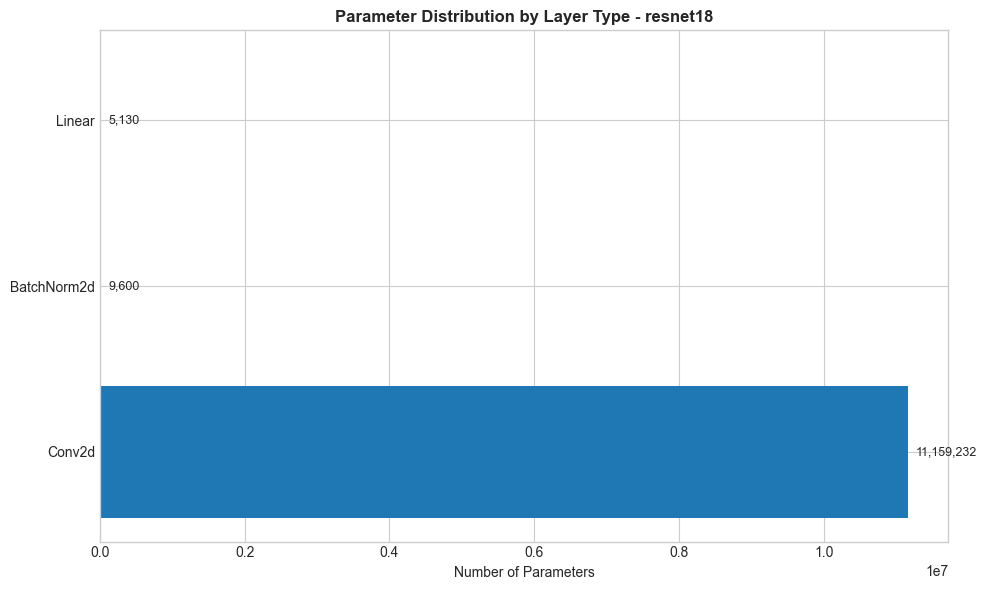

In [63]:
# Parameter distribution by layer type
layer_params = {}
for name, module in model.named_modules():
    layer_type = type(module).__name__
    params = sum(p.numel() for p in module.parameters(recurse=False))
    if params > 0:
        if layer_type not in layer_params:
            layer_params[layer_type] = 0
        layer_params[layer_type] += params

# Plot parameter distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
layer_types = list(layer_params.keys())
param_counts = list(layer_params.values())

colors = plt.cm.tab10(np.linspace(0, 1, len(layer_types)))
bars = ax.barh(layer_types, param_counts, color=colors)
ax.set_xlabel('Number of Parameters')
ax.set_title(f'Parameter Distribution by Layer Type - {MODEL_NAME}', fontweight='bold')

# Add value labels
for bar, count in zip(bars, param_counts):
    ax.text(bar.get_width() + max(param_counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Inference Benchmark <a id='4-benchmark'></a>

In [64]:
def benchmark_inference(model, input_size=(1, 3, 32, 32), warmup=50, iterations=200):
    """Benchmark model inference speed."""
    model.eval()
    x = torch.randn(input_size).to(device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)
    
    # Synchronize if using CUDA
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Benchmark
    times = []
    with torch.no_grad():
        for _ in range(iterations):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)  # Convert to ms
    
    return {
        'mean_ms': np.mean(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
        'throughput': input_size[0] * 1000 / np.mean(times)  # images per second
    }

# Benchmark at different batch sizes
batch_sizes = [1, 4, 16, 32, 64, 128]
benchmark_results = []

print("Benchmarking inference speed...")
for bs in batch_sizes:
    result = benchmark_inference(model, input_size=(bs, 3, 32, 32))
    result['batch_size'] = bs
    benchmark_results.append(result)
    print(f"  Batch {bs:3d}: {result['mean_ms']:.2f} ms (Throughput: {result['throughput']:.0f} img/s)")

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df

Benchmarking inference speed...
  Batch   1: 5.71 ms (Throughput: 175 img/s)
  Batch   4: 5.73 ms (Throughput: 699 img/s)
  Batch  16: 7.38 ms (Throughput: 2167 img/s)
  Batch  32: 11.83 ms (Throughput: 2705 img/s)
  Batch  64: 21.72 ms (Throughput: 2946 img/s)
  Batch 128: 40.66 ms (Throughput: 3148 img/s)


,mean_ms,std_ms,min_ms,max_ms,throughput,batch_size
0,5.709249,2.368491,3.0723,17.8746,175.154385,1
1,5.725151,2.384763,2.9856,14.0425,698.671467,4
2,7.382381,3.121009,5.8106,28.8158,2167.322293,16
3,11.830011,1.000677,11.2165,18.2065,2704.984805,32
4,21.723531,1.751413,20.8968,34.8757,2946.113987,64
5,40.664714,0.727835,40.0835,49.1198,3147.692124,128


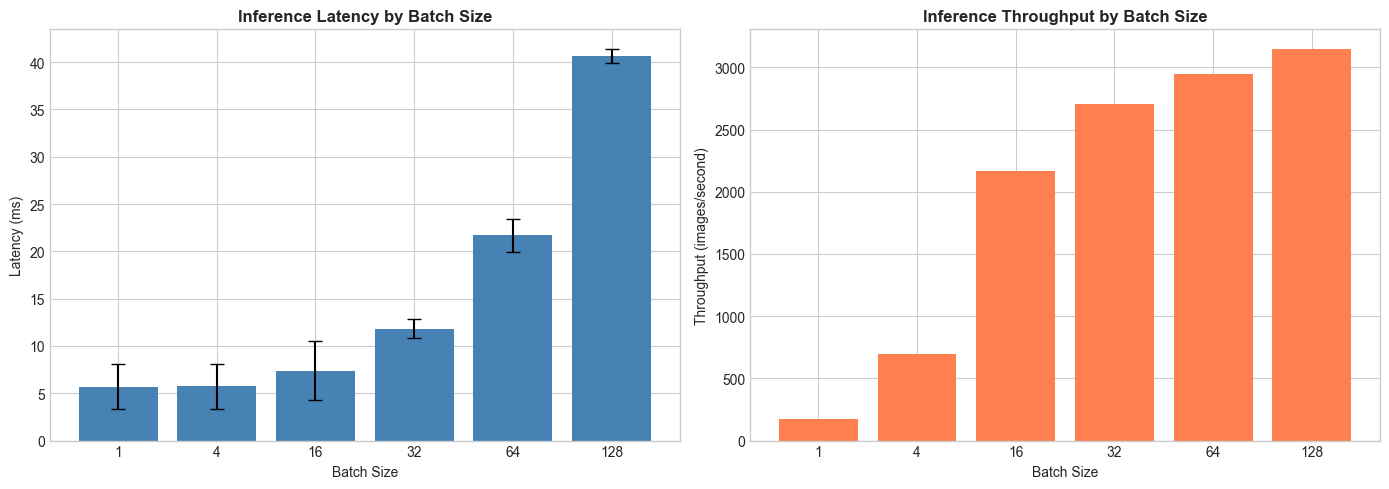

In [65]:
# Visualize benchmark results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency
axes[0].bar(range(len(batch_sizes)), benchmark_df['mean_ms'], 
            yerr=benchmark_df['std_ms'], capsize=5, color='steelblue')
axes[0].set_xticks(range(len(batch_sizes)))
axes[0].set_xticklabels(batch_sizes)
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Inference Latency by Batch Size', fontweight='bold')

# Throughput
axes[1].bar(range(len(batch_sizes)), benchmark_df['throughput'], color='coral')
axes[1].set_xticks(range(len(batch_sizes)))
axes[1].set_xticklabels(batch_sizes)
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Throughput (images/second)')
axes[1].set_title('Inference Throughput by Batch Size', fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/inference_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Accuracy Evaluation <a id='5-accuracy'></a>

In [66]:
# Load test dataset
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=transform_test
)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], 
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Test dataset size: {len(test_dataset)}")

Files already downloaded and verified
Test dataset size: 10000


In [67]:
def evaluate_model(model, dataloader):
    """Evaluate model and collect predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Evaluating model...")
predictions, labels, probabilities = evaluate_model(model, test_loader)

# Calculate accuracy
accuracy = (predictions == labels).mean() * 100
print(f"\nTest Accuracy: {accuracy:.2f}%")

Evaluating model...

Test Accuracy: 9.44%


In [68]:
# Detailed classification report
print("\nClassification Report:")
print("="*70)
print(classification_report(labels, predictions, target_names=CLASS_NAMES, digits=4))


Classification Report:
              precision    recall  f1-score   support

    airplane     0.0000    0.0000    0.0000      1000
  automobile     0.0986    0.9310    0.1783      1000
        bird     0.0000    0.0000    0.0000      1000
         cat     0.0000    0.0000    0.0000      1000
        deer     0.0000    0.0000    0.0000      1000
         dog     0.0000    0.0000    0.0000      1000
        frog     0.0000    0.0000    0.0000      1000
       horse     0.0000    0.0000    0.0000      1000
        ship     0.0240    0.0130    0.0169      1000
       truck     0.0000    0.0000    0.0000      1000

    accuracy                         0.0944     10000
   macro avg     0.0123    0.0944    0.0195     10000
weighted avg     0.0123    0.0944    0.0195     10000



## 6. Confusion Matrix <a id='6-confusion-matrix'></a>

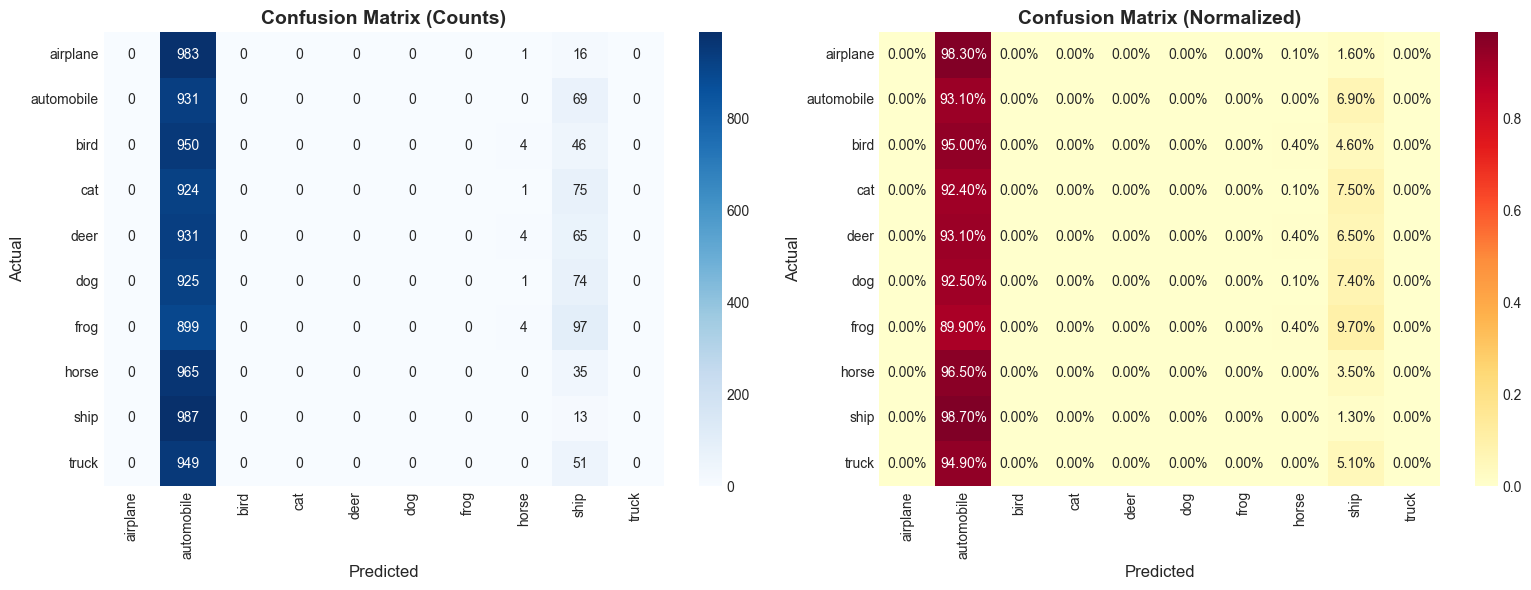

In [69]:
# Compute confusion matrix
cm = confusion_matrix(labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
# Most confused pairs
cm_off_diagonal = cm.copy()
np.fill_diagonal(cm_off_diagonal, 0)

# Find top confused pairs
confused_pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm_off_diagonal[i, j] > 0:
            confused_pairs.append({
                'actual': CLASS_NAMES[i],
                'predicted': CLASS_NAMES[j],
                'count': cm_off_diagonal[i, j],
                'rate': cm_off_diagonal[i, j] / cm[i].sum() * 100
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('count', ascending=False)
print("Top 10 Most Confused Pairs:")
confused_df.head(10)

Top 10 Most Confused Pairs:


,actual,predicted,count,rate
21,ship,automobile,987,98.7
0,airplane,automobile,983,98.3
19,horse,automobile,965,96.5
4,bird,automobile,950,95.0
22,truck,automobile,949,94.9
10,deer,automobile,931,93.1
13,dog,automobile,925,92.5
7,cat,automobile,924,92.4
16,frog,automobile,899,89.9
18,frog,ship,97,9.7


## 7. Per-Class Analysis <a id='7-per-class'></a>

In [71]:
# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    labels, predictions, average=None
)

per_class_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'Accuracy': [cm[i, i] / cm[i].sum() * 100 for i in range(len(CLASS_NAMES))]
})

per_class_df = per_class_df.round(4)
print("Per-Class Metrics:")
per_class_df

Per-Class Metrics:


,Class,Precision,Recall,F1-Score,Support,Accuracy
0,airplane,0.0000,0.000,0.0000,1000,0.0
1,automobile,0.0986,0.931,0.1783,1000,93.1
2,bird,0.0000,0.000,0.0000,1000,0.0
3,cat,0.0000,0.000,0.0000,1000,0.0
4,deer,0.0000,0.000,0.0000,1000,0.0
5,dog,0.0000,0.000,0.0000,1000,0.0
6,frog,0.0000,0.000,0.0000,1000,0.0
7,horse,0.0000,0.000,0.0000,1000,0.0
8,ship,0.0240,0.013,0.0169,1000,1.3
9,truck,0.0000,0.000,0.0000,1000,0.0


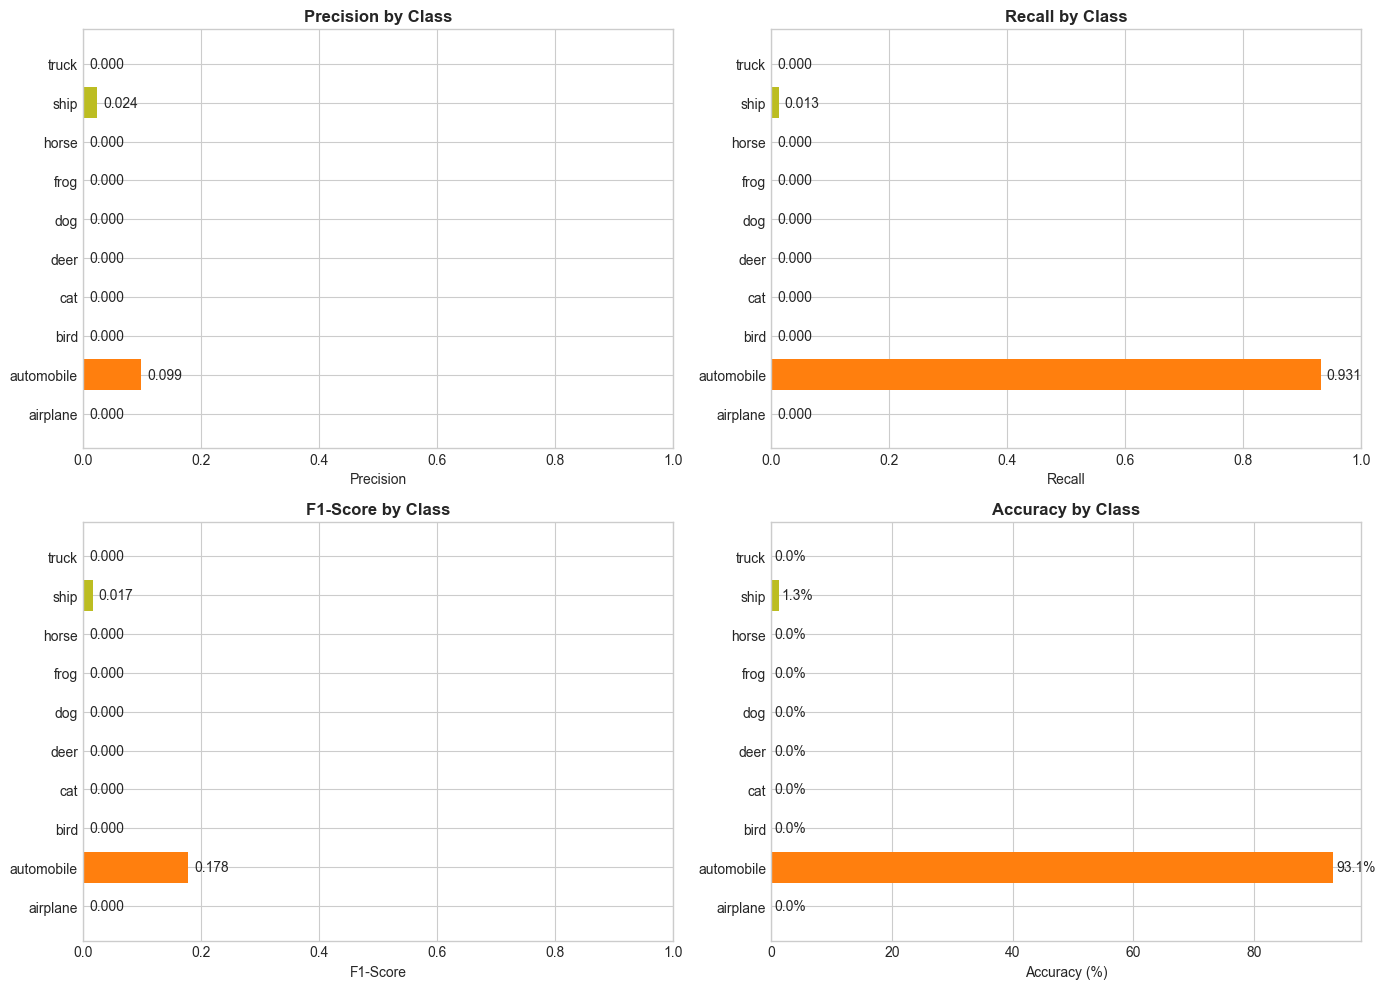

In [72]:
# Visualize per-class performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Precision
axes[0, 0].barh(CLASS_NAMES, per_class_df['Precision'], color=colors)
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_title('Precision by Class', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(per_class_df['Precision']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Recall
axes[0, 1].barh(CLASS_NAMES, per_class_df['Recall'], color=colors)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall by Class', fontweight='bold')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(per_class_df['Recall']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

# F1-Score
axes[1, 0].barh(CLASS_NAMES, per_class_df['F1-Score'], color=colors)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score by Class', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(per_class_df['F1-Score']):
    axes[1, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Accuracy
axes[1, 1].barh(CLASS_NAMES, per_class_df['Accuracy'], color=colors)
axes[1, 1].set_xlabel('Accuracy (%)')
axes[1, 1].set_title('Accuracy by Class', fontweight='bold')
for i, v in enumerate(per_class_df['Accuracy']):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../experiments/results/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

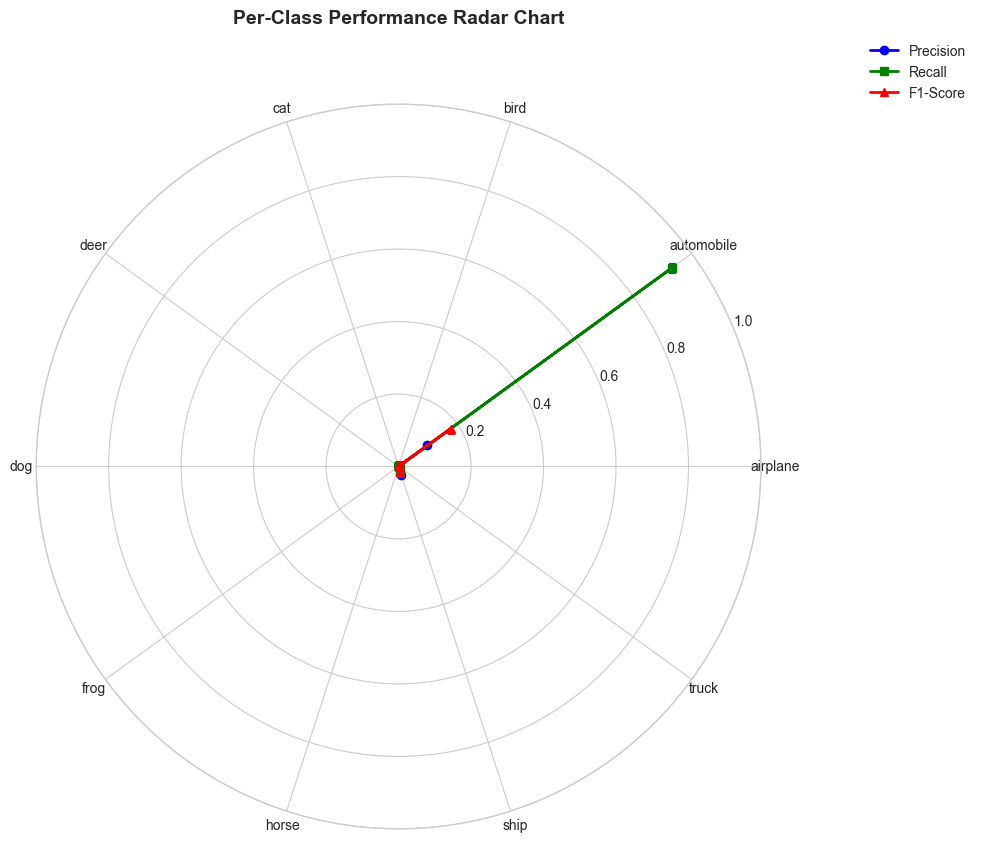

In [73]:
# Radar chart for per-class comparison
from math import pi

# Number of variables
categories = CLASS_NAMES
N = len(categories)

# Angles for each category
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot each metric
for metric, color, marker in [('Precision', 'blue', 'o'), 
                               ('Recall', 'green', 's'), 
                               ('F1-Score', 'red', '^')]:
    values = per_class_df[metric].tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, color=color, linewidth=2, marker=marker, label=metric)
    ax.fill(angles, values, color=color, alpha=0.1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Per-Class Performance Radar Chart', fontsize=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../experiments/results/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Visualization <a id='8-features'></a>

In [74]:
# Extract features from model
def extract_features(model, dataloader, layer_name=None):
    """Extract features from a specific layer."""
    model.eval()
    features = []
    all_labels = []
    
    # Hook to capture features
    feature_output = []
    def hook(module, input, output):
        feature_output.append(output.detach().cpu())
    
    # Register hook on the layer before the final classifier
    # For ResNet, this is typically avgpool
    if hasattr(model, 'avgpool'):
        handle = model.avgpool.register_forward_hook(hook)
    elif hasattr(model, 'global_pool'):
        handle = model.global_pool.register_forward_hook(hook)
    else:
        # Find the layer before fc
        for name, module in model.named_modules():
            if 'pool' in name.lower() or 'flatten' in name.lower():
                handle = module.register_forward_hook(hook)
                break
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            _ = model(images)
            all_labels.extend(labels.numpy())
    
    handle.remove()
    
    # Combine features
    all_features = torch.cat(feature_output, dim=0)
    all_features = all_features.view(all_features.size(0), -1).numpy()
    
    return all_features, np.array(all_labels)

print("Extracting features (this may take a moment)...")
features, feature_labels = extract_features(model, test_loader)
print(f"Features shape: {features.shape}")

Extracting features (this may take a moment)...
Features shape: (10000, 512)


In [75]:
# T-SNE on extracted features
print("Computing T-SNE on features...")

# Sample if too many
max_samples = 5000
if len(features) > max_samples:
    indices = np.random.choice(len(features), max_samples, replace=False)
    features_sample = features[indices]
    labels_sample = feature_labels[indices]
else:
    features_sample = features
    labels_sample = feature_labels

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
features_tsne = tsne.fit_transform(features_sample)

print("Done!")

Computing T-SNE on features...
Done!


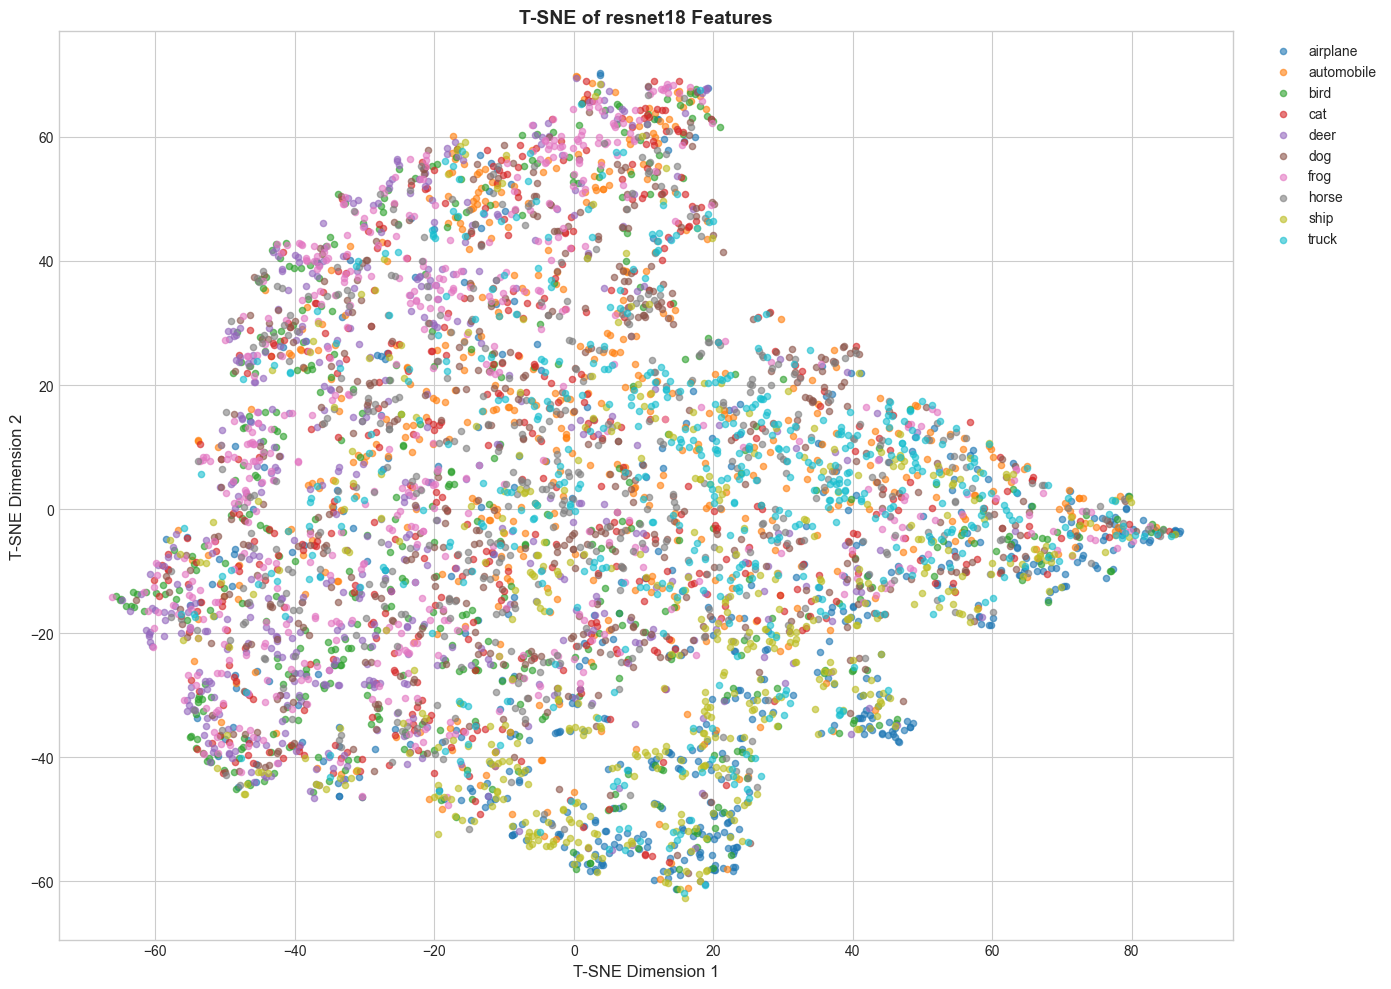

In [76]:
# Plot T-SNE of features
plt.figure(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = labels_sample == class_idx
    plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1],
                c=[colors[class_idx]], label=class_name, alpha=0.6, s=20)

plt.xlabel('T-SNE Dimension 1', fontsize=12)
plt.ylabel('T-SNE Dimension 2', fontsize=12)
plt.title(f'T-SNE of {MODEL_NAME} Features', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../experiments/results/feature_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Comparison <a id='9-comparison'></a>

In [77]:
# Compare multiple models (if available)
def compare_models(model_configs, test_loader):
    """Compare multiple models."""
    results = []
    
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        try:
            model = load_model(config['model'], CONFIG['num_classes'], config.get('weights'))
            
            # Count parameters
            total_params = sum(p.numel() for p in model.parameters())
            
            # Benchmark
            benchmark = benchmark_inference(model, input_size=(1, 3, 32, 32))
            
            # Evaluate
            preds, labels, _ = evaluate_model(model, test_loader)
            accuracy = (preds == labels).mean() * 100
            
            results.append({
                'Model': config['name'],
                'Parameters (M)': total_params / 1e6,
                'Latency (ms)': benchmark['mean_ms'],
                'Throughput (img/s)': benchmark['throughput'],
                'Accuracy (%)': accuracy
            })
            
        except Exception as e:
            print(f"  Error: {e}")
    
    return pd.DataFrame(results)

# Define models to compare
model_configs = [
    {'name': 'ResNet18', 'model': 'resnet18', 'weights': None},
    # Add more models here
    # {'name': 'ResNet18-Ghost', 'model': 'resnet18_ghost', 'weights': '../weights/resnet18_ghost.pth'},
]

if len(model_configs) > 1:
    comparison_df = compare_models(model_configs, test_loader)
    print("\nModel Comparison Results:")
    comparison_df
else:
    print("Add more models to model_configs for comparison.")

Add more models to model_configs for comparison.


## 10. Export Results <a id='10-export'></a>

In [78]:
# Save all results
results_dir = '../experiments/results'
os.makedirs(results_dir, exist_ok=True)

# Save per-class metrics
per_class_df.to_csv(f'{results_dir}/per_class_metrics.csv', index=False)
print(f"Saved: per_class_metrics.csv")

# Save benchmark results
benchmark_df.to_csv(f'{results_dir}/benchmark_results.csv', index=False)
print(f"Saved: benchmark_results.csv")

# Save confusion matrix
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(f'{results_dir}/confusion_matrix.csv')
print(f"Saved: confusion_matrix.csv")

# Save summary
summary_results = {
    'model_name': MODEL_NAME,
    'test_accuracy': float(accuracy),
    'total_params': sum(p.numel() for p in model.parameters()),
    'inference_latency_ms': float(benchmark_df[benchmark_df['batch_size']==1]['mean_ms'].values[0]),
    'throughput_bs128': float(benchmark_df[benchmark_df['batch_size']==128]['throughput'].values[0]),
}

with open(f'{results_dir}/model_summary.json', 'w') as f:
    json.dump(summary_results, f, indent=2)
print(f"Saved: model_summary.json")

print(f"\nAll results saved to: {results_dir}")

Saved: per_class_metrics.csv
Saved: benchmark_results.csv
Saved: confusion_matrix.csv
Saved: model_summary.json

All results saved to: ../experiments/results


In [79]:
# Final summary
print("="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"""
Model: {MODEL_NAME}

Performance:
   - Test Accuracy: {accuracy:.2f}%
   - Parameters: {sum(p.numel() for p in model.parameters()):,}
   
Speed (Batch Size 1):
   - Latency: {benchmark_df[benchmark_df['batch_size']==1]['mean_ms'].values[0]:.2f} ms
   - Throughput: {benchmark_df[benchmark_df['batch_size']==1]['throughput'].values[0]:.0f} img/s

Best Performing Classes:
""")

top_classes = per_class_df.nlargest(3, 'F1-Score')[['Class', 'F1-Score', 'Accuracy']]
for _, row in top_classes.iterrows():
    print(f"   - {row['Class']}: F1={row['F1-Score']:.4f}, Acc={row['Accuracy']:.1f}%")

print("\nClasses Needing Improvement:")
bottom_classes = per_class_df.nsmallest(3, 'F1-Score')[['Class', 'F1-Score', 'Accuracy']]
for _, row in bottom_classes.iterrows():
    print(f"   - {row['Class']}: F1={row['F1-Score']:.4f}, Acc={row['Accuracy']:.1f}%")

MODEL PERFORMANCE SUMMARY

Model: resnet18

Performance:
   - Test Accuracy: 9.44%
   - Parameters: 11,173,962

Speed (Batch Size 1):
   - Latency: 5.71 ms
   - Throughput: 175 img/s

Best Performing Classes:

   - automobile: F1=0.1783, Acc=93.1%
   - ship: F1=0.0169, Acc=1.3%
   - airplane: F1=0.0000, Acc=0.0%

Classes Needing Improvement:
   - airplane: F1=0.0000, Acc=0.0%
   - bird: F1=0.0000, Acc=0.0%
   - cat: F1=0.0000, Acc=0.0%


---

*Model Performance Analysis - ResNet Optimization Research Project*

# Model Performance Analysis

**ResNet Optimization Research Project**

Notebook ini berisi analisis performa model yang telah ditraining:

## Daftar Isi
1. [Setup](#1-setup)
2. [Load Model dan Weights](#2-load-model)
3. [Model Architecture Analysis](#3-architecture)
4. [Inference Speed Benchmark](#4-benchmark)
5. [Accuracy Evaluation](#5-accuracy)
6. [Confusion Matrix](#6-confusion-matrix)
7. [Per-Class Analysis](#7-per-class)
8. [Feature Visualization](#8-features)
9. [Model Comparison](#9-comparison)
10. [Export Results](#10-export)

## 1. Setup <a id='1-setup'></a>

In [80]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary

# Sklearn
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    precision_recall_fscore_support, roc_curve, auc
)
from sklearn.manifold import TSNE

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Add parent directory
sys.path.append(os.path.dirname(os.path.abspath('')))

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory: 6.4 GB


In [81]:
try:
    from models import create_model, get_model_info
    from utils.dataloader import get_dataloaders
    from utils.metrics import calculate_metrics
    print("Custom modules imported successfully")
except ImportError as e:
    print(f"Could not import custom modules: {e}")
    print("Using fallback implementations...")

Could not import custom modules: cannot import name 'get_dataloaders' from 'utils.dataloader' (c:\Users\Rafif Fikri\OneDrive\Documents\Optimasi_ResNet\utils\dataloader.py)
Using fallback implementations...


In [82]:
# Configuration
CONFIG = {
    'dataset': 'cifar10',
    'data_dir': '../data',
    'weights_dir': '../weights',
    'batch_size': 128,
    'num_workers': 4,
    'num_classes': 10,
}

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Normalization values
MEAN = [0.4914, 0.4822, 0.4465]
STD = [0.2470, 0.2435, 0.2616]

print("Configuration loaded.")

Configuration loaded.


## 2. Load Model dan Weights <a id='2-load-model'></a>

In [83]:
# List available weights
weights_dir = CONFIG['weights_dir']
if os.path.exists(weights_dir):
    weight_files = [f for f in os.listdir(weights_dir) if f.endswith('.pth')]
    print(f"Available weight files ({len(weight_files)}):")
    for f in weight_files:
        size_mb = os.path.getsize(os.path.join(weights_dir, f)) / (1024*1024)
        print(f"   - {f} ({size_mb:.2f} MB)")
else:
    print(f"⚠️ Weights directory not found: {weights_dir}")
    print("Creating directory...")
    os.makedirs(weights_dir, exist_ok=True)

Available weight files (0):


In [84]:
# Function to load model
def load_model(model_name, num_classes=10, weights_path=None):
    """Load a model with optional pretrained weights."""
    try:
        model = create_model(model_name, num_classes=num_classes)
    except:
        # Fallback to torchvision
        if 'resnet18' in model_name:
            model = torchvision.models.resnet18(num_classes=num_classes)
        elif 'resnet34' in model_name:
            model = torchvision.models.resnet34(num_classes=num_classes)
        elif 'resnet50' in model_name:
            model = torchvision.models.resnet50(num_classes=num_classes)
        else:
            raise ValueError(f"Unknown model: {model_name}")
    
    if weights_path and os.path.exists(weights_path):
        checkpoint = torch.load(weights_path, map_location=device)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        elif 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print(f"Loaded weights from {weights_path}")
    
    return model.to(device)

# Load model (modify as needed)
MODEL_NAME = 'resnet18'  # Change this to your model
WEIGHTS_PATH = None  # Set to your weights file path

model = load_model(MODEL_NAME, CONFIG['num_classes'], WEIGHTS_PATH)
model.eval()
print(f"\nModel loaded: {MODEL_NAME}")


Model loaded: resnet18


## 3. Model Architecture Analysis <a id='3-architecture'></a>

In [85]:
# Model summary
print("Model Architecture Summary:")
print("="*70)

try:
    model_summary = summary(
        model,
        input_size=(1, 3, 32, 32),
        col_names=['input_size', 'output_size', 'num_params', 'mult_adds'],
        verbose=0
    )
    print(model_summary)
except:
    # Fallback
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

Model Architecture Summary:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
ResNet                                   [1, 3, 32, 32]            [1, 10]                   --                        --
├─Conv2d: 1-1                            [1, 3, 32, 32]            [1, 64, 32, 32]           1,728                     1,769,472
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           [1, 64, 32, 32]           128                       128
├─ReLU: 1-3                              [1, 64, 32, 32]           [1, 64, 32, 32]           --                        --
├─Sequential: 1-4                        [1, 64, 32, 32]           [1, 64, 32, 32]           --                        --
│    └─BasicBlock: 2-1                   [1, 64, 32, 32]           [1, 64, 32, 32]           --                        --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           [1, 64, 32, 32]           36,864    

In [86]:
# Layer-wise analysis
def analyze_layers(model):
    """Analyze model layers."""
    layer_info = []
    
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Leaf modules only
            num_params = sum(p.numel() for p in module.parameters())
            if num_params > 0:
                layer_info.append({
                    'name': name,
                    'type': module.__class__.__name__,
                    'params': num_params
                })
    
    return pd.DataFrame(layer_info)

layer_df = analyze_layers(model)
print(f"\nNumber of parameterized layers: {len(layer_df)}")

# Show top layers by parameters
print("\nTop 10 layers by parameters:")
layer_df.nlargest(10, 'params')


Number of parameterized layers: 41

Top 10 layers by parameters:


,name,type,params
32,layer4.0.conv2,Conv2d,2359296
36,layer4.1.conv1,Conv2d,2359296
38,layer4.1.conv2,Conv2d,2359296
30,layer4.0.conv1,Conv2d,1179648
22,layer3.0.conv2,Conv2d,589824
26,layer3.1.conv1,Conv2d,589824
28,layer3.1.conv2,Conv2d,589824
20,layer3.0.conv1,Conv2d,294912
12,layer2.0.conv2,Conv2d,147456
16,layer2.1.conv1,Conv2d,147456


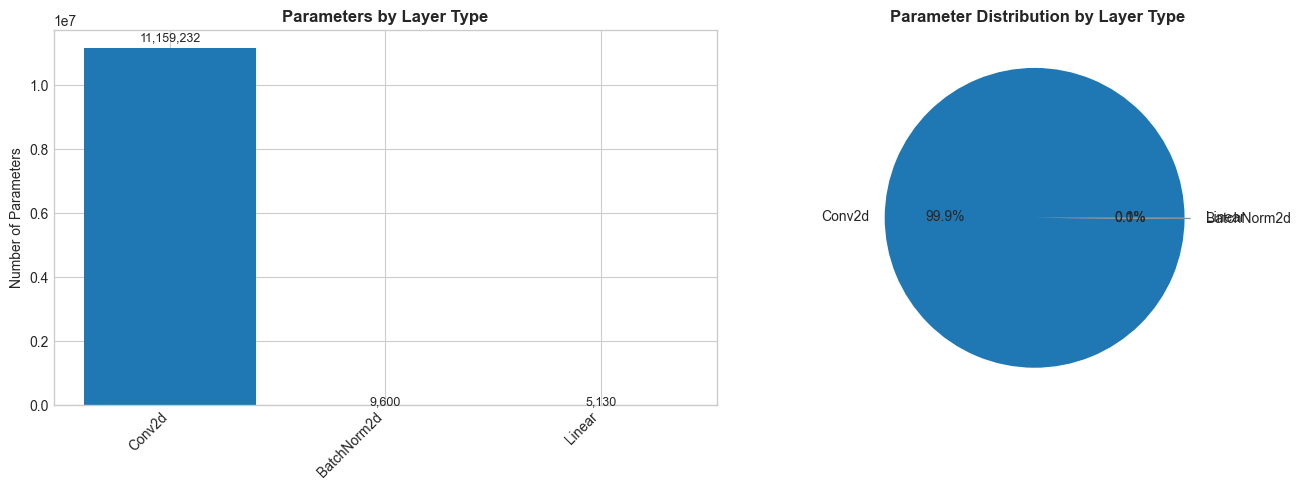

In [88]:
# Visualize parameter distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameters by layer type
type_params = layer_df.groupby('type')['params'].sum().sort_values(ascending=False)
colors = plt.cm.tab10(np.linspace(0, 1, len(type_params)))

axes[0].bar(range(len(type_params)), type_params.values, color=colors)
axes[0].set_xticks(range(len(type_params)))
axes[0].set_xticklabels(type_params.index, rotation=45, ha='right')
axes[0].set_ylabel('Number of Parameters')
axes[0].set_title('Parameters by Layer Type', fontweight='bold')

# Add value labels
for i, (idx, val) in enumerate(type_params.items()):
    axes[0].text(i, val + val*0.02, f'{val:,}', ha='center', fontsize=9)

# Pie chart of layer type distribution
axes[1].pie(type_params.values, labels=type_params.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02]*len(type_params))
axes[1].set_title('Parameter Distribution by Layer Type', fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/model_parameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Inference Speed Benchmark <a id='4-benchmark'></a>

In [89]:
def benchmark_inference(model, input_size=(1, 3, 32, 32), num_iterations=100, warmup=10):
    """Benchmark model inference speed."""
    model.eval()
    x = torch.randn(input_size).to(device)
    
    # Warmup
    for _ in range(warmup):
        with torch.no_grad():
            _ = model(x)
    
    # Synchronize CUDA
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Benchmark
    times = []
    for _ in range(num_iterations):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        start = time.perf_counter()
        with torch.no_grad():
            _ = model(x)
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        end = time.perf_counter()
        times.append((end - start) * 1000)  # ms
    
    return {
        'mean_ms': np.mean(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
        'throughput': 1000 / np.mean(times) * input_size[0]  # images/sec
    }

# Run benchmark
print("Running inference benchmark...")
batch_sizes = [1, 8, 16, 32, 64, 128]
benchmark_results = []

for bs in batch_sizes:
    result = benchmark_inference(model, input_size=(bs, 3, 32, 32))
    result['batch_size'] = bs
    benchmark_results.append(result)
    print(f"  Batch {bs}: {result['mean_ms']:.2f} ± {result['std_ms']:.2f} ms, "
          f"Throughput: {result['throughput']:.0f} img/s")

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df

Running inference benchmark...
  Batch 1: 8.25 ± 1.88 ms, Throughput: 121 img/s
  Batch 8: 13.07 ± 2.85 ms, Throughput: 612 img/s
  Batch 16: 18.96 ± 3.76 ms, Throughput: 844 img/s
  Batch 32: 45.92 ± 43.83 ms, Throughput: 697 img/s
  Batch 64: 81.03 ± 61.44 ms, Throughput: 790 img/s
  Batch 128: 125.76 ± 28.51 ms, Throughput: 1018 img/s


,mean_ms,std_ms,min_ms,max_ms,throughput,batch_size
0,8.250252,1.875988,4.7523,14.7631,121.208419,1
1,13.067512,2.851943,6.7282,22.9981,612.205292,8
2,18.962757,3.758349,13.0089,40.3399,843.759164,16
3,45.917536,43.834009,25.0617,287.3317,696.901506,32
4,81.029672,61.443465,38.9621,389.9542,789.834124,64
5,125.755525,28.507617,82.0491,384.2447,1017.847924,128


In [ ]:
# Visualize benchmark results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency
axes[0].errorbar(benchmark_df['batch_size'], benchmark_df['mean_ms'],
                 yerr=benchmark_df['std_ms'], marker='o', capsize=5,
                 linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Batch Size', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Inference Latency vs Batch Size', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Throughput
axes[1].bar(range(len(batch_sizes)), benchmark_df['throughput'], color='green', alpha=0.7)
axes[1].set_xticks(range(len(batch_sizes)))
axes[1].set_xticklabels(batch_sizes)
axes[1].set_xlabel('Batch Size', fontsize=12)
axes[1].set_ylabel('Throughput (images/sec)', fontsize=12)
axes[1].set_title('Inference Throughput', fontweight='bold')

for i, v in enumerate(benchmark_df['throughput']):
    axes[1].text(i, v + v*0.02, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../experiments/results/inference_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Accuracy Evaluation <a id='5-accuracy'></a>

In [ ]:
# Load test data
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG['data_dir'], train=False, download=True, transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Test dataset loaded: {len(test_dataset):,} samples")

In [ ]:
# Evaluate model
def evaluate_model(model, dataloader):
    """Evaluate model on a dataset."""
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Evaluating model...")
predictions, labels, probabilities = evaluate_model(model, test_loader)

# Calculate accuracy
accuracy = (predictions == labels).mean() * 100
print(f"\nTest Accuracy: {accuracy:.2f}%")

In [ ]:
# Detailed classification report
print("\nClassification Report:")
print("="*70)
print(classification_report(labels, predictions, target_names=CLASS_NAMES, digits=4))

## 6. Confusion Matrix <a id='6-confusion-matrix'></a>

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Most confused pairs
cm_off_diagonal = cm.copy()
np.fill_diagonal(cm_off_diagonal, 0)

# Find top confused pairs
confused_pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm_off_diagonal[i, j] > 0:
            confused_pairs.append({
                'actual': CLASS_NAMES[i],
                'predicted': CLASS_NAMES[j],
                'count': cm_off_diagonal[i, j],
                'rate': cm_off_diagonal[i, j] / cm[i].sum() * 100
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('count', ascending=False)
print("Top 10 Most Confused Pairs:")
confused_df.head(10)

## 7. Per-Class Analysis <a id='7-per-class'></a>

In [ ]:
# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    labels, predictions, average=None
)

per_class_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'Accuracy': [cm[i, i] / cm[i].sum() * 100 for i in range(len(CLASS_NAMES))]
})

per_class_df = per_class_df.round(4)
print("Per-Class Metrics:")
per_class_df

In [ ]:
# Visualize per-class performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Precision
axes[0, 0].barh(CLASS_NAMES, per_class_df['Precision'], color=colors)
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_title('Precision by Class', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(per_class_df['Precision']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Recall
axes[0, 1].barh(CLASS_NAMES, per_class_df['Recall'], color=colors)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall by Class', fontweight='bold')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(per_class_df['Recall']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

# F1-Score
axes[1, 0].barh(CLASS_NAMES, per_class_df['F1-Score'], color=colors)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score by Class', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(per_class_df['F1-Score']):
    axes[1, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Accuracy
axes[1, 1].barh(CLASS_NAMES, per_class_df['Accuracy'], color=colors)
axes[1, 1].set_xlabel('Accuracy (%)')
axes[1, 1].set_title('Accuracy by Class', fontweight='bold')
for i, v in enumerate(per_class_df['Accuracy']):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../experiments/results/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Radar chart for per-class comparison
from math import pi

# Number of variables
categories = CLASS_NAMES
N = len(categories)

# Angles for each category
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot each metric
for metric, color, marker in [('Precision', 'blue', 'o'), 
                               ('Recall', 'green', 's'), 
                               ('F1-Score', 'red', '^')]:
    values = per_class_df[metric].tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, color=color, linewidth=2, marker=marker, label=metric)
    ax.fill(angles, values, color=color, alpha=0.1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Per-Class Performance Radar Chart', fontsize=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../experiments/results/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Visualization <a id='8-features'></a>

In [ ]:
# Extract features from model
def extract_features(model, dataloader, layer_name=None):
    """Extract features from a specific layer."""
    model.eval()
    features = []
    all_labels = []
    
    # Hook to capture features
    feature_output = []
    def hook(module, input, output):
        feature_output.append(output.detach().cpu())
    
    # Register hook on the layer before the final classifier
    # For ResNet, this is typically avgpool
    if hasattr(model, 'avgpool'):
        handle = model.avgpool.register_forward_hook(hook)
    elif hasattr(model, 'global_pool'):
        handle = model.global_pool.register_forward_hook(hook)
    else:
        # Find the layer before fc
        for name, module in model.named_modules():
            if 'pool' in name.lower() or 'flatten' in name.lower():
                handle = module.register_forward_hook(hook)
                break
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            _ = model(images)
            all_labels.extend(labels.numpy())
    
    handle.remove()
    
    # Combine features
    all_features = torch.cat(feature_output, dim=0)
    all_features = all_features.view(all_features.size(0), -1).numpy()
    
    return all_features, np.array(all_labels)

print("Extracting features (this may take a moment)...")
features, feature_labels = extract_features(model, test_loader)
print(f"Features shape: {features.shape}")

In [ ]:
# T-SNE on extracted features
print("Computing T-SNE on features...")

# Sample if too many
max_samples = 5000
if len(features) > max_samples:
    indices = np.random.choice(len(features), max_samples, replace=False)
    features_sample = features[indices]
    labels_sample = feature_labels[indices]
else:
    features_sample = features
    labels_sample = feature_labels

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
features_tsne = tsne.fit_transform(features_sample)

print("Done!")

In [ ]:
# Plot T-SNE of features
plt.figure(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = labels_sample == class_idx
    plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1],
                c=[colors[class_idx]], label=class_name, alpha=0.6, s=20)

plt.xlabel('T-SNE Dimension 1', fontsize=12)
plt.ylabel('T-SNE Dimension 2', fontsize=12)
plt.title(f'T-SNE of {MODEL_NAME} Features', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../experiments/results/feature_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Comparison <a id='9-comparison'></a>

In [ ]:
# Compare multiple models (if available)
def compare_models(model_configs, test_loader):
    """Compare multiple models."""
    results = []
    
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        try:
            model = load_model(config['model'], CONFIG['num_classes'], config.get('weights'))
            
            # Count parameters
            total_params = sum(p.numel() for p in model.parameters())
            
            # Benchmark
            benchmark = benchmark_inference(model, input_size=(1, 3, 32, 32))
            
            # Evaluate
            preds, labels, _ = evaluate_model(model, test_loader)
            accuracy = (preds == labels).mean() * 100
            
            results.append({
                'Model': config['name'],
                'Parameters (M)': total_params / 1e6,
                'Latency (ms)': benchmark['mean_ms'],
                'Throughput (img/s)': benchmark['throughput'],
                'Accuracy (%)': accuracy
            })
            
        except Exception as e:
            print(f"  Error: {e}")
    
    return pd.DataFrame(results)

# Define models to compare
model_configs = [
    {'name': 'ResNet18', 'model': 'resnet18', 'weights': None},
    # Add more models here
    # {'name': 'ResNet18-Ghost', 'model': 'resnet18_ghost', 'weights': '../weights/resnet18_ghost.pth'},
]

if len(model_configs) > 1:
    comparison_df = compare_models(model_configs, test_loader)
    print("\nModel Comparison Results:")
    comparison_df
else:
    print("Add more models to model_configs for comparison.")

## 10. Export Results <a id='10-export'></a>

In [ ]:
# Save all results
results_dir = '../experiments/results'
os.makedirs(results_dir, exist_ok=True)

# Save per-class metrics
per_class_df.to_csv(f'{results_dir}/per_class_metrics.csv', index=False)
print(f\"Saved: per_class_metrics.csv\")

# Save benchmark results
benchmark_df.to_csv(f'{results_dir}/benchmark_results.csv', index=False)
print(f\"Saved: benchmark_results.csv\")

# Save confusion matrix
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(f'{results_dir}/confusion_matrix.csv')
print(f\"Saved: confusion_matrix.csv\")

# Save summary
summary_results = {
    'model_name': MODEL_NAME,
    'test_accuracy': float(accuracy),
    'total_params': sum(p.numel() for p in model.parameters()),
    'inference_latency_ms': float(benchmark_df[benchmark_df['batch_size']==1]['mean_ms'].values[0]),
    'throughput_bs128': float(benchmark_df[benchmark_df['batch_size']==128]['throughput'].values[0]),
}

with open(f'{results_dir}/model_summary.json', 'w') as f:
    json.dump(summary_results, f, indent=2)
print(f"✅ Saved: model_summary.json")

print(f"\nAll results saved to: {results_dir}")

In [ ]:
# Final summary
print("="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"""
Model: {MODEL_NAME}

Performance:
   - Test Accuracy: {accuracy:.2f}%
   - Parameters: {sum(p.numel() for p in model.parameters()):,}
   
Speed (Batch Size 1):
   - Latency: {benchmark_df[benchmark_df['batch_size']==1]['mean_ms'].values[0]:.2f} ms
   - Throughput: {benchmark_df[benchmark_df['batch_size']==1]['throughput'].values[0]:.0f} img/s

Best Performing Classes:
""")

top_classes = per_class_df.nlargest(3, 'F1-Score')[['Class', 'F1-Score', 'Accuracy']]
for _, row in top_classes.iterrows():
    print(f"   - {row['Class']}: F1={row['F1-Score']:.4f}, Acc={row['Accuracy']:.1f}%")

print("\n🔻 Classes Needing Improvement:")
bottom_classes = per_class_df.nsmallest(3, 'F1-Score')[['Class', 'F1-Score', 'Accuracy']]
for _, row in bottom_classes.iterrows():
    print(f"   - {row['Class']}: F1={row['F1-Score']:.4f}, Acc={row['Accuracy']:.1f}%")

---

*Model Performance Analysis - ResNet Optimization Research Project*